## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../../Mamoth Modules")
sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)


In [6]:
dataset

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623
1,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427
2,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.081799
3,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,1.822118
4,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.011088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-27,27,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,14336.000000,13975.000000,14225.483871,14431.214286,14457.548387,14457.548387,13753.419355,13812.821429,13782.645161,13782.645161,0.000000
3143172,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14336.000000,13975.000000,14225.483871,14431.214286,14457.548387,14457.548387,13753.419355,13812.821429,13782.645161,13782.645161,0.000000
3143173,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-29,29,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,14312.000000,13956.000000,14225.483871,14431.214286,14457.548387,14457.548387,13753.419355,13812.821429,13782.645161,13782.645161,0.000000
3143174,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-30,30,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,14190.000000,13905.000000,14225.483871,14431.214286,14457.548387,14457.548387,13753.419355,13812.821429,13782.645161,13782.645161,0.000000


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset.shape

(3143176, 31)

In [9]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [10]:
dataset2 = pd.DataFrame()
groups = dataset.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset2 = dataset2.append(temp_df)

dataset2.reset_index(drop=True, inplace=True)

In [11]:
dataset2

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,τρικαλων,θεσσαλιας,21.190130,39.661480,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.941204,40.941204,40.941204,40.941204
1,τρικαλων,θεσσαλιας,21.190130,39.661480,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.769920,63.711124,63.711124,63.711124
2,τρικαλων,θεσσαλιας,21.190130,39.661480,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007012,64.718136,64.718136,64.718136
3,τρικαλων,θεσσαλιας,21.190130,39.661480,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.641527,68.359663,68.359663,68.359663
4,τρικαλων,θεσσαλιας,21.190130,39.661480,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.385432,69.745094,69.745094,69.745094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,μαγνησιας,θεσσαλιας,23.299620,39.203270,2022-12-27,27,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,0.000000,7.205815,1157.374877
3143172,μαγνησιας,θεσσαλιας,23.299620,39.203270,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14356.000000,14182.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,0.000000,0.000000,1157.374877
3143173,μαγνησιας,θεσσαλιας,23.299620,39.203270,2022-12-29,29,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14356.000000,14079.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,0.000000,0.000000,1157.374877
3143174,μαγνησιας,θεσσαλιας,23.299620,39.203270,2022-12-30,30,12,2022,0.437406,0.346100,-0.301129,-0.346100,0.446126,0.341544,-0.308838,-0.341544,0.023620,0.029441,0.029670,0.029441,14239.000000,14096.000000,14172.233333,14288.214286,14180.451613,14180.451613,13971.129032,13995.285714,13929.000000,13929.000000,0.000000,0.000000,0.000000,1157.374877


In [12]:
grouped = dataset2.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.037500,NaN,14470.037500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.050513,38.050513,38.050513,38.050513
1,2010-01-01,λαρισας,θεσσαλιας,22.405497,39.703383,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14453.085185,NaN,NaN,NaN,13949.820513,NaN,NaN,NaN,1.096759,1.096759,1.096759,1.096759
2,2010-01-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14497.808511,NaN,NaN,NaN,14026.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,0.071117
3,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14418.375000,13915.473684,14418.375000,NaN,NaN,NaN,13915.473684,NaN,NaN,NaN,39.913539,39.913539,39.913539,39.913539
4,2010-01-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14325.966292,13912.623188,14374.089888,NaN,NaN,NaN,13912.623188,NaN,NaN,NaN,15.711856,53.762369,53.762369,53.762369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,τρικαλων,θεσσαλιας,21.591863,39.641569,30.000000,12.000000,2022.000000,0.301352,0.101026,-0.231860,-0.101026,0.252016,0.118255,-0.185997,-0.118255,0.047931,0.058056,0.053729,0.058056,14095.921687,13797.873494,14029.473572,14181.773236,14144.990284,14144.990284,13684.835406,13701.400325,13649.974687,13649.974687,0.000000,0.000000,0.494781,1068.335984
18988,2022-12-31,καρδιτσας,θεσσαλιας,21.891852,39.318887,31.000000,12.000000,2022.000000,0.268452,0.059572,-0.203921,-0.059572,0.240353,0.061059,-0.178930,-0.061059,0.052645,0.050411,0.051347,0.050411,14173.268293,13831.772358,14080.062156,14251.302265,14264.063467,14264.063467,13707.331760,13740.956736,13711.728822,13711.728822,0.000000,0.004299,0.015514,973.065268
18989,2022-12-31,λαρισας,θεσσαλιας,22.405497,39.703383,31.000000,12.000000,2022.000000,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,14233.707581,13838.884477,14140.530263,14329.032491,14362.054967,14362.054967,13677.785373,13726.381912,13683.083615,13683.083615,0.000000,0.056918,0.066263,1096.486878
18990,2022-12-31,μαγνησιας,θεσσαλιας,22.869212,39.281871,31.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,14208.270833,13917.229167,14118.090952,14244.585938,14209.986223,14209.986223,13822.483871,13838.325149,13777.013441,13777.013441,0.000000,0.000000,0.004880,1046.578644


In [13]:
dataset.shape

(18992, 34)

In [14]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.037500,NaN,14470.037500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.050513,38.050513,38.050513,38.050513
1,2010-01-01,λαρισας,θεσσαλιας,22.405497,39.703383,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14453.085185,NaN,NaN,NaN,13949.820513,NaN,NaN,NaN,1.096759,1.096759,1.096759,1.096759
2,2010-01-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14497.808511,NaN,NaN,NaN,14026.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,0.071117
3,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14418.375000,13915.473684,14418.375000,NaN,NaN,NaN,13915.473684,NaN,NaN,NaN,39.913539,39.913539,39.913539,39.913539
4,2010-01-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14325.966292,13912.623188,14374.089888,NaN,NaN,NaN,13912.623188,NaN,NaN,NaN,15.711856,53.762369,53.762369,53.762369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,τρικαλων,θεσσαλιας,21.591863,39.641569,30.000000,12.000000,2022.000000,0.301352,0.101026,-0.231860,-0.101026,0.252016,0.118255,-0.185997,-0.118255,0.047931,0.058056,0.053729,0.058056,14095.921687,13797.873494,14029.473572,14181.773236,14144.990284,14144.990284,13684.835406,13701.400325,13649.974687,13649.974687,0.000000,0.000000,0.494781,1068.335984
18988,2022-12-31,καρδιτσας,θεσσαλιας,21.891852,39.318887,31.000000,12.000000,2022.000000,0.268452,0.059572,-0.203921,-0.059572,0.240353,0.061059,-0.178930,-0.061059,0.052645,0.050411,0.051347,0.050411,14173.268293,13831.772358,14080.062156,14251.302265,14264.063467,14264.063467,13707.331760,13740.956736,13711.728822,13711.728822,0.000000,0.004299,0.015514,973.065268
18989,2022-12-31,λαρισας,θεσσαλιας,22.405497,39.703383,31.000000,12.000000,2022.000000,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,14233.707581,13838.884477,14140.530263,14329.032491,14362.054967,14362.054967,13677.785373,13726.381912,13683.083615,13683.083615,0.000000,0.056918,0.066263,1096.486878
18990,2022-12-31,μαγνησιας,θεσσαλιας,22.869212,39.281871,31.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,14208.270833,13917.229167,14118.090952,14244.585938,14209.986223,14209.986223,13822.483871,13838.325149,13777.013441,13777.013441,0.000000,0.000000,0.004880,1046.578644


In [16]:
# dataset['lst_jan_mean'] = (dataset['lst_day_jan_mean'] + dataset['lst_night_jan_mean'])/2
# dataset['lst_feb_mean'] = (dataset['lst_day_feb_mean'] + dataset['lst_night_feb_mean'])/2
# dataset['lst_mar_mean'] = (dataset['lst_day_mar_mean'] + dataset['lst_night_mar_mean'])/2
# dataset['lst_apr_mean'] = (dataset['lst_day_apr_mean'] + dataset['lst_night_apr_mean'])/2

In [17]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [18]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [19]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.037500,NaN,14470.037500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.050513,38.050513,38.050513,38.050513,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14453.085185,NaN,NaN,NaN,13949.820513,NaN,NaN,NaN,1.096759,1.096759,1.096759,1.096759,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14497.808511,NaN,NaN,NaN,14026.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,0.071117,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14418.375000,13915.473684,14418.375000,NaN,NaN,NaN,13915.473684,NaN,NaN,NaN,39.913539,39.913539,39.913539,39.913539,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14325.966292,13912.623188,14374.089888,NaN,NaN,NaN,13912.623188,NaN,NaN,NaN,15.711856,53.762369,53.762369,53.762369,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,τρικαλων,θεσσαλιας,21.591863,39.641569,30,12,2022,0.301352,0.101026,-0.231860,-0.101026,0.252016,0.118255,-0.185997,-0.118255,0.047931,0.058056,0.053729,0.058056,14095.921687,13797.873494,14029.473572,14181.773236,14144.990284,14144.990284,13684.835406,13701.400325,13649.974687,13649.974687,0.000000,0.000000,0.494781,1068.335984,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981
18988,2022-12-31,καρδιτσας,θεσσαλιας,21.891852,39.318887,31,12,2022,0.268452,0.059572,-0.203921,-0.059572,0.240353,0.061059,-0.178930,-0.061059,0.052645,0.050411,0.051347,0.050411,14173.268293,13831.772358,14080.062156,14251.302265,14264.063467,14264.063467,13707.331760,13740.956736,13711.728822,13711.728822,0.000000,0.004299,0.015514,973.065268,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18989,2022-12-31,λαρισας,θεσσαλιας,22.405497,39.703383,31,12,2022,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,14233.707581,13838.884477,14140.530263,14329.032491,14362.054967,14362.054967,13677.785373,13726.381912,13683.083615,13683.083615,0.000000,0.056918,0.066263,1096.486878,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18990,2022-12-31,μαγνησιας,θεσσαλιας,22.869212,39.281871,31,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,14208.270833,13917.229167,14118.090952,14244.585938,14209.986223,14209.986223,13822.483871,13838.325149,13777.013441,13777.013441,0.000000,0.000000,0.004880,1046.578644,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [20]:
dataset.reset_index(drop=True, inplace=True)

<AxesSubplot:>

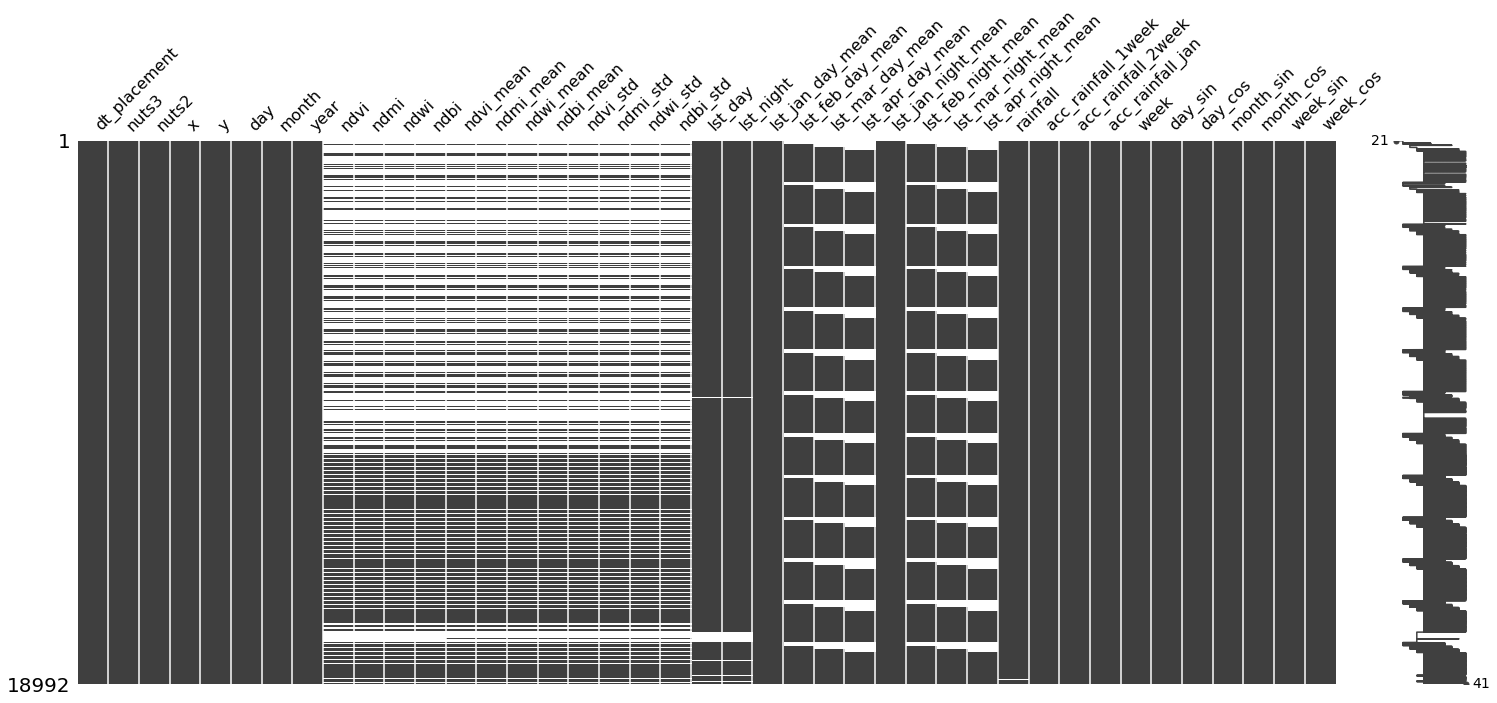

In [21]:
missingno.matrix(dataset)

In [22]:
print(dataset.columns)

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'day', 'month', 'year',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean',
       'lst_apr_day_mean', 'lst_jan_night_mean', 'lst_feb_night_mean',
       'lst_mar_night_mean', 'lst_apr_night_mean', 'rainfall',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 'week',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos'],
      dtype='object')


In [23]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [24]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [25]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [26]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [27]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


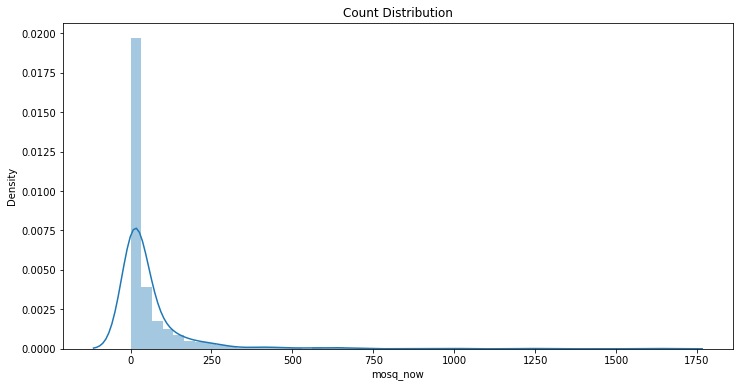

In [28]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [29]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_16264/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


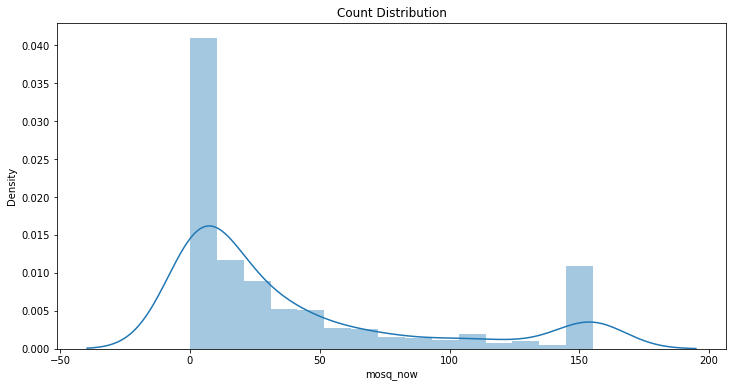

In [30]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

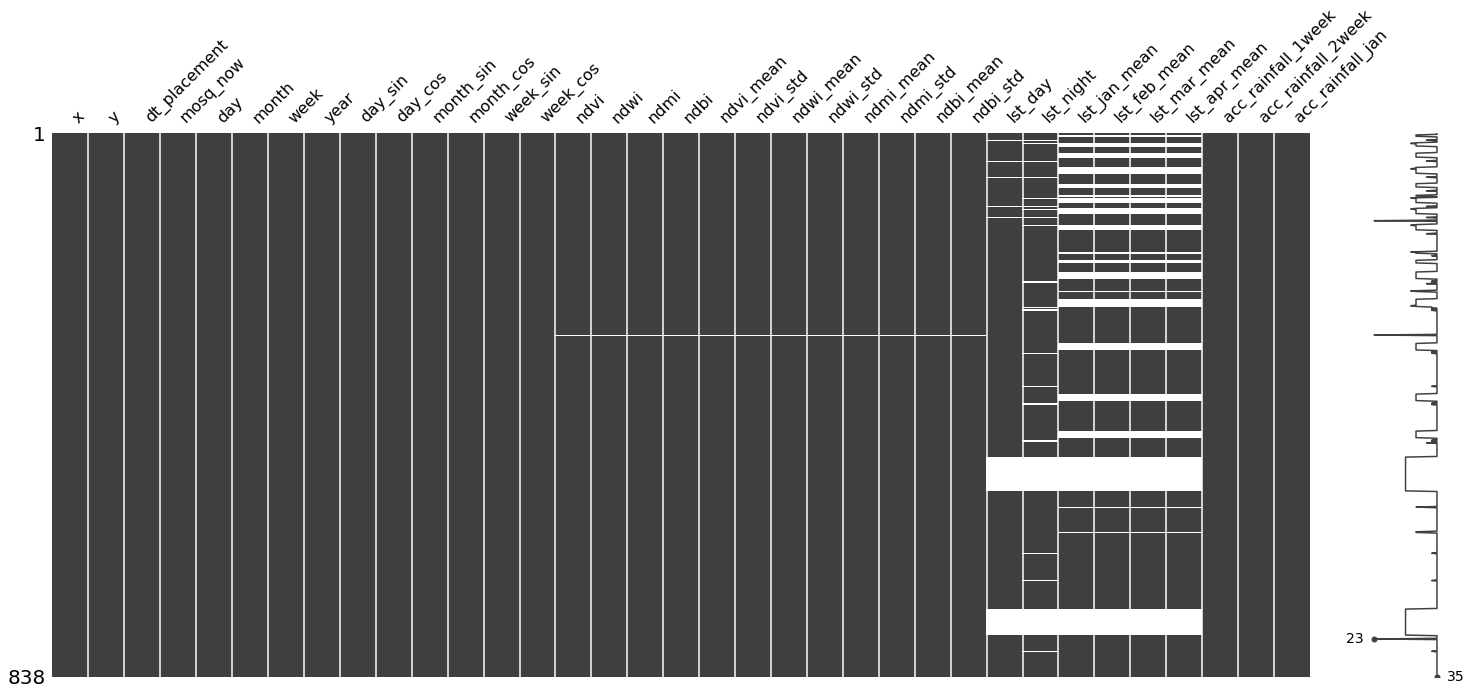

In [31]:
missingno.matrix(mosquito_data_nuts2)

In [32]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [33]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

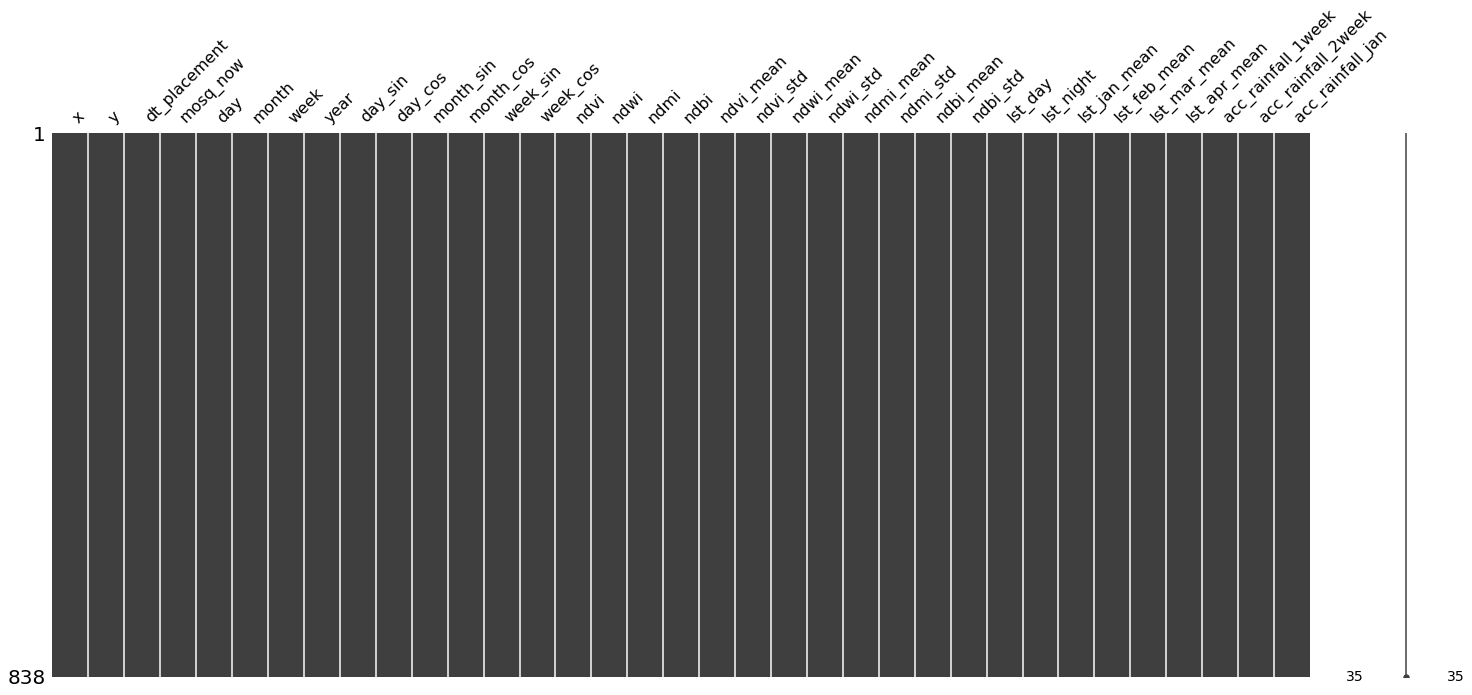

In [34]:
missingno.matrix(mosquito_data_nuts2)

In [35]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [36]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [37]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.84173 | Val Loss: 29.27278 | Train Acc: 4.453| Val Acc: 3.468
Epoch 002: | Train Loss: 37.77449 | Val Loss: 28.42479 | Train Acc: 3.776| Val Acc: 3.296
Epoch 003: | Train Loss: 35.88074 | Val Loss: 28.69242 | Train Acc: 3.296| Val Acc: 3.251
Epoch 004: | Train Loss: 35.15336 | Val Loss: 27.01190 | Train Acc: 3.068| Val Acc: 2.943
Epoch 005: | Train Loss: 33.88294 | Val Loss: 25.98303 | Train Acc: 2.884| Val Acc: 2.826
Epoch 006: | Train Loss: 33.68596 | Val Loss: 24.97089 | Train Acc: 2.798| Val Acc: 2.410
Epoch 007: | Train Loss: 33.37531 | Val Loss: 24.61466 | Train Acc: 2.815| Val Acc: 2.381
Epoch 008: | Train Loss: 33.03469 | Val Loss: 24.34078 | Train Acc: 2.778| Val Acc: 2.406
Epoch 009: | Train Loss: 32.86975 | Val Loss: 23.79879 | Train Acc: 2.731| Val Acc: 2.233
Epoch 010: | Train Loss: 32.54634 | Val Loss: 23.90047 | Train Acc: 2.664| Val Acc: 2.183
Epoch 011: | Train Loss: 32.54737 | Val Loss: 23.58641 | Train Acc: 2.687| Val Acc: 1.819
Epoch 012:

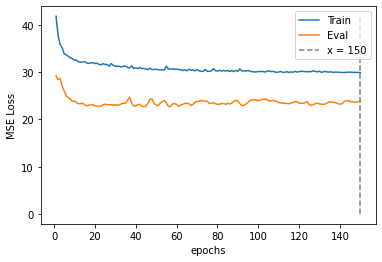

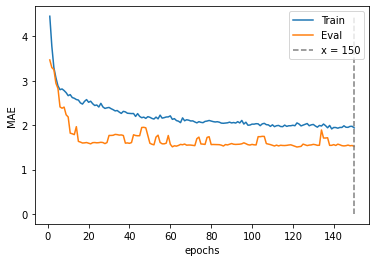

In [38]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [39]:
metrics(train, test, threshold=30)

MAE on train set:  23.064349582799146
min prediction: 1
max prediction: 156

MAE on test set:  24.08167932416088
Error ⩽ 30: 67.94 %
min prediction: 1
max prediction: 164


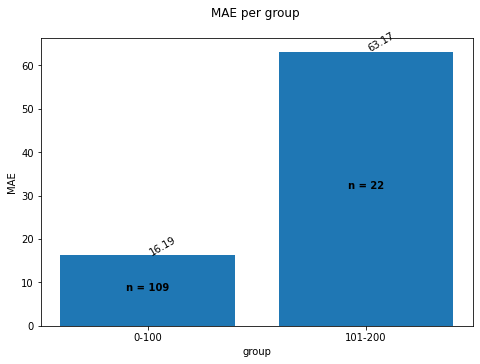

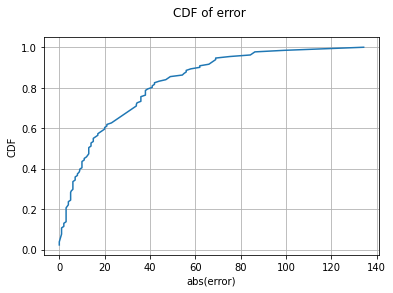

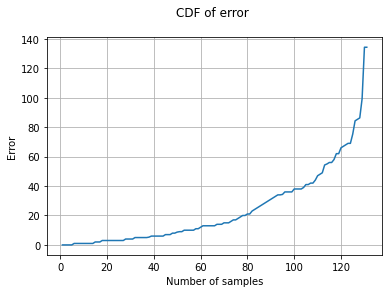

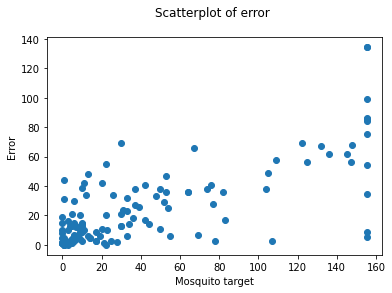

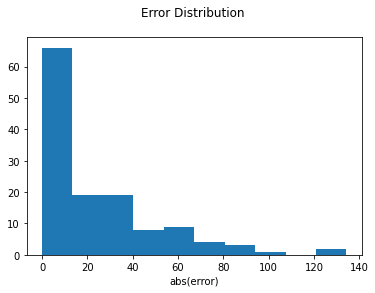

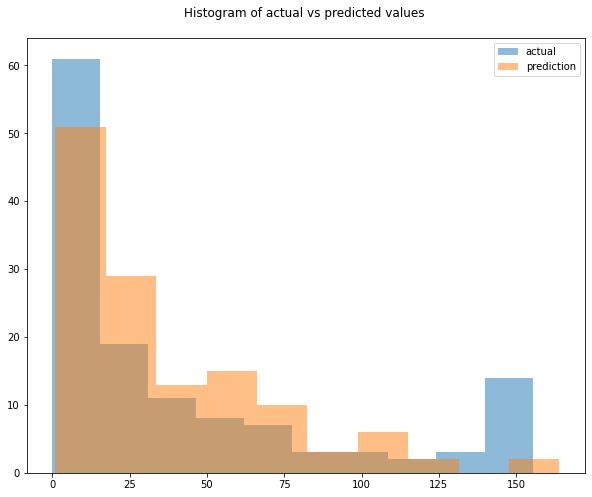

In [40]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 34.35286 | Val Loss: 0.00122 | Train Acc: 2.460| Val Acc: 0.045
Epoch 002: | Train Loss: 33.75625 | Val Loss: 0.05414 | Train Acc: 2.355| Val Acc: 0.045
Epoch 003: | Train Loss: 33.41722 | Val Loss: 0.06264 | Train Acc: 2.298| Val Acc: 0.045
Epoch 004: | Train Loss: 33.28895 | Val Loss: 0.00741 | Train Acc: 2.275| Val Acc: 0.045
Epoch 005: | Train Loss: 33.20834 | Val Loss: 0.17679 | Train Acc: 2.317| Val Acc: 0.045
Epoch 006: | Train Loss: 33.05015 | Val Loss: 0.41294 | Train Acc: 2.299| Val Acc: 1.045
Epoch 007: | Train Loss: 32.81096 | Val Loss: 0.20736 | Train Acc: 2.292| Val Acc: 0.045
Epoch 008: | Train Loss: 32.50653 | Val Loss: 0.01907 | Train Acc: 2.155| Val Acc: 0.045
Epoch 009: | Train Loss: 32.73202 | Val Loss: 0.01996 | Train Acc: 2.195| Val Acc: 0.045
Epoch 010: | Train Loss: 32.51447 | Val Loss: 0.03865 | Train Acc: 2.190| Val Acc: 0.045
Epoch 011: | Train Loss: 32.54013 | Val Loss: 0.04372 | Train Acc: 2.168| Val Acc: 0.045
Epoch 012: | Train Lo

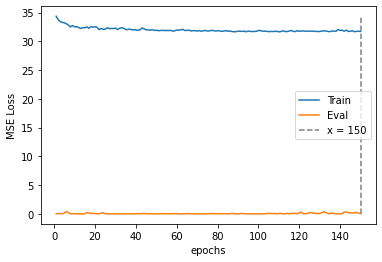

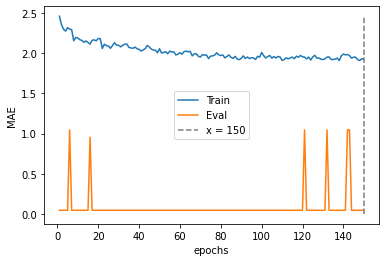

In [41]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [42]:
columns_to_keep

['x',
 'y',
 'dt_placement',
 'day',
 'month',
 'week',
 'year',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'ndvi',
 'ndwi',
 'ndmi',
 'ndbi',
 'ndvi_mean',
 'ndvi_std',
 'ndwi_mean',
 'ndwi_std',
 'ndmi_mean',
 'ndmi_std',
 'ndbi_mean',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'acc_rainfall_jan',
 'mosq_now']

In [43]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14470.037500,NaN,14470.037500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.050513,38.050513,38.050513,38.050513,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14453.085185,13949.820513,14453.085185,NaN,NaN,NaN,13949.820513,NaN,NaN,NaN,1.096759,1.096759,1.096759,1.096759,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14497.808511,14026.800000,14497.808511,NaN,NaN,NaN,14026.800000,NaN,NaN,NaN,0.071117,0.071117,0.071117,0.071117,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14418.375000,13915.473684,14418.375000,NaN,NaN,NaN,13915.473684,NaN,NaN,NaN,39.913539,39.913539,39.913539,39.913539,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14325.966292,13912.623188,14374.089888,NaN,NaN,NaN,13912.623188,NaN,NaN,NaN,15.711856,53.762369,53.762369,53.762369,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,τρικαλων,θεσσαλιας,21.591863,39.641569,30,12,2022,0.301352,0.101026,-0.231860,-0.101026,0.252016,0.118255,-0.185997,-0.118255,0.047931,0.058056,0.053729,0.058056,14095.921687,13797.873494,14029.473572,14181.773236,14144.990284,14144.990284,13684.835406,13701.400325,13649.974687,13649.974687,0.000000,0.000000,0.494781,1068.335984,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981
18988,2022-12-31,καρδιτσας,θεσσαλιας,21.891852,39.318887,31,12,2022,0.268452,0.059572,-0.203921,-0.059572,0.240353,0.061059,-0.178930,-0.061059,0.052645,0.050411,0.051347,0.050411,14173.268293,13831.772358,14080.062156,14251.302265,14264.063467,14264.063467,13707.331760,13740.956736,13711.728822,13711.728822,0.000000,0.004299,0.015514,973.065268,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18989,2022-12-31,λαρισας,θεσσαλιας,22.405497,39.703383,31,12,2022,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,14233.707581,13838.884477,14140.530263,14329.032491,14362.054967,14362.054967,13677.785373,13726.381912,13683.083615,13683.083615,0.000000,0.056918,0.066263,1096.486878,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
18990,2022-12-31,μαγνησιας,θεσσαλιας,22.869212,39.281871,31,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,14208.270833,13917.229167,14118.090952,14244.585938,14209.986223,14209.986223,13822.483871,13838.325149,13777.013441,13777.013441,0.000000,0.000000,0.004880,1046.578644,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [44]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep, mean_lst = True)

In [45]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [46]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [47]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [48]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [49]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

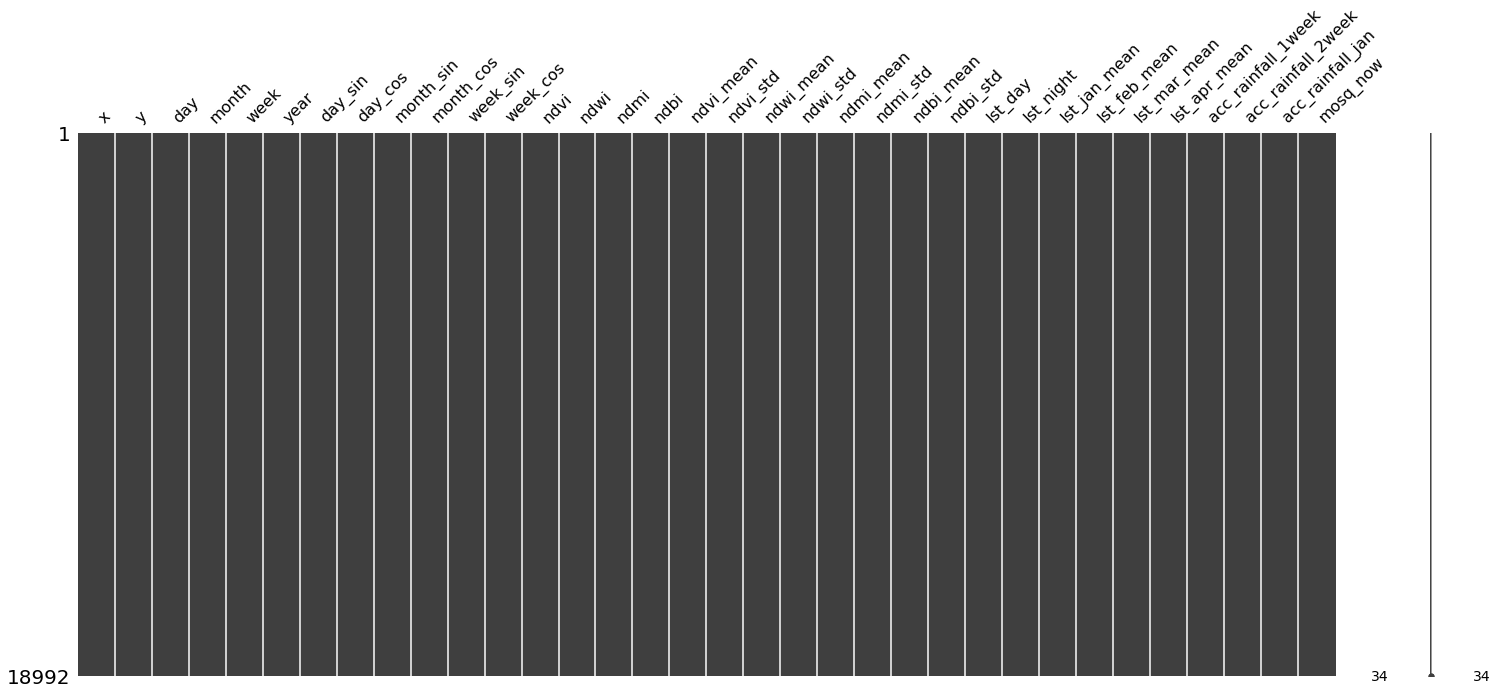

In [50]:
missingno.matrix(dataset_mamoth)

In [51]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [52]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [53]:
predictions = give_predictions(model, dataset_mamoth)

In [54]:
mosqutio_predictions['mosq_pred'] = predictions

In [55]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.891852,39.318887,2010-01-01,1
1,22.405497,39.703383,2010-01-01,3
2,22.869212,39.281871,2010-01-01,1
3,21.591863,39.641569,2010-01-01,21
4,21.891852,39.318887,2010-01-02,1
...,...,...,...,...
18987,21.591863,39.641569,2022-12-30,444
18988,21.891852,39.318887,2022-12-31,180
18989,22.405497,39.703383,2022-12-31,206
18990,22.869212,39.281871,2022-12-31,62


In [56]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', index = False)